In [1]:
from pathlib import Path
ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / ".projectroot").exists())

# GSDB Global Sanctions : EDA + Preparation

The Global Sanctions Data Base records sanctions cases between states, with start and end dates. Being under sanctions marks a country as a target of international pressure, so this gives the risk model a measure of each country's sanctions exposure.

**Input:** `data/raw/gsdb/GSDB_V4_dyadic.dta` (dyadic, sanctioning state to sanctioned state, in force 1950 to 2023).
**Output:** `data/interim/gsdb/gsdb_clean.csv` (one row per target country-year, keyed on ISO3).

## 1. Setup and Load

I import the libraries and set the raw and output folder paths.

In [2]:
import os
import numpy as np
import pandas as pd

RAW = str(ROOT / "data/raw/gsdb/GSDB_V4_dyadic.dta")
OUT_DIR = str(ROOT / "data/interim/gsdb")
TYPES = ['arms', 'military', 'trade', 'financial', 'travel', 'other']
pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 160)

I set one consistent, high-resolution style for every chart (resolution, fonts, sizes, colors).

In [3]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.dpi': 130, 'savefig.dpi': 200,
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'font.family': 'DejaVu Sans', 'font.size': 11,
    'axes.titlesize': 14, 'axes.titleweight': 'bold', 'axes.labelsize': 12,
    'axes.edgecolor': '#444444', 'axes.linewidth': 0.8,
    'axes.grid': True, 'grid.color': '#E9E9E9', 'grid.linewidth': 0.8,
    'xtick.labelsize': 10, 'ytick.labelsize': 10,
    'axes.spines.top': False, 'axes.spines.right': False, 'legend.frameon': False,
})
NAVY, BLUE, RED = '#1F3864', '#2E75B6', '#C0392B'

I load the dyadic Stata file, convert the datetime year to a plain integer year, then check its shape and the type of every column.

In [4]:
g = pd.read_stata(RAW)
g['year'] = pd.to_datetime(g['year']).dt.year
print('register ->', g.shape, '| year range:', g['year'].min(), '-', g['year'].max())
g.dtypes.to_frame('dtype')

register -> (159065, 17) | year range: 1950 - 2023


,dtype
case_id,object
sanctioning_state_iso3,object
sanctioning_state,object
sanctioned_state_iso3,object
sanctioned_state,object
year,int32
arms,int8
military,int8
trade,int8
descr_trade,object


The register holds 159,065 dyad-years across 17 columns, spanning 1950 to 2023. Each row is one sanction case in force in one year, from a sanctioning state to a sanctioned state, with ISO3 codes already supplied for both sides and six type indicator flags (arms, military, trade, financial, travel, other). I aggregate to the sanctioned (target) side, so a country's exposure is how many sanctions are imposed on it.

## 2. Data Discovery

I look at the first rows to see the actual values in each column.

In [5]:
g.head(8)

,case_id,sanctioning_state_iso3,sanctioning_state,sanctioned_state_iso3,sanctioned_state,year,arms,military,trade,descr_trade,financial,travel,other,target_mult,sender_mult,objective,success
0,471,AFG,Afghanistan,AGO,Angola,1993,1,1,1,exp_part,0,0,0,0,1,end_war,success_total
1,471,AFG,Afghanistan,AGO,Angola,1994,1,1,1,exp_part,0,0,0,0,1,end_war,success_total
2,471,AFG,Afghanistan,AGO,Angola,1995,1,1,1,exp_part,0,0,0,0,1,end_war,success_total
3,471,AFG,Afghanistan,AGO,Angola,1996,1,1,1,exp_part,0,0,0,0,1,end_war,success_total
4,"471,574",AFG,Afghanistan,AGO,Angola,1997,1,1,1,exp_part,0,1,1,0,1,"end_war,end_war","success_total,success_total"
5,"574,595,471",AFG,Afghanistan,AGO,Angola,1998,1,1,1,"exp_part,imp_part",1,1,1,0,1,"end_war,end_war,end_war","success_total,success_total,success_total"
6,"595,471,574",AFG,Afghanistan,AGO,Angola,1999,1,1,1,"exp_part,imp_part",1,1,1,0,1,"end_war,end_war,end_war","success_total,success_total,success_total"
7,"595,471,574",AFG,Afghanistan,AGO,Angola,2000,1,1,1,"exp_part,imp_part",1,1,1,0,1,"end_war,end_war,end_war","success_total,success_total,success_total"


`g` = dyadic GSDB, one row per sanctioned-sanctioning-state-year.

- Each row = one sanction relationship in one year: who sanctions whom, the case it belongs to, and which of the six channels are active.
- Example (first row): in 1993 (year), Afghanistan (sanctioning_state, AFG) sanctioned Angola (sanctioned_state, AGO) under case 471, an arms + military + partial-export trade sanction (arms 1, military 1, trade 1, descr_trade exp_part), with objective end_war and success success_total.
- case_id can merge several cases on one dyad-year (row 4 shows 471,574), so counting distinct cases later needs a comma split.
- I aggregate to the sanctioned (target) side, so AGO here gains one unit of sanctions exposure.

I check the register for fully duplicate rows and the share missing in each column.

In [6]:
print('duplicate full rows:', g.duplicated().sum())
miss = g.replace(r'^\s*$', np.nan, regex=True).isna().mean() * 100
miss.round(2).to_frame('missing_%')

duplicate full rows: 0


,missing_%
case_id,0.00
sanctioning_state_iso3,0.00
sanctioning_state,0.00
sanctioned_state_iso3,5.57
sanctioned_state,0.00
year,0.00
arms,0.00
military,0.00
trade,0.00
descr_trade,64.92


With blank strings counted, two columns show real missing values: sanctioned_state_iso3 is 5.57% empty (the four non-state Terrorist Organizations targets, checked next) and descr_trade is 64.92% empty (blank whenever there is no trade sanction). Every field I aggregate on, the ISO3 codes, year, and the six type flags, is fully populated, and there are no duplicate rows. So the only rows I drop are the non-country targets.

The ISO3 codes are supplied, so before grouping I check whether every sanctioned-side code is a clean 3-letter code, and list any that are not so I can drop non-country targets.

In [7]:
bad = g[~g['sanctioned_state_iso3'].str.match(r'^[A-Za-z]{3}$', na=False)]
print('invalid target-ISO3 dyad-years:', len(bad))
(bad.groupby(['sanctioned_state_iso3', 'sanctioned_state'], dropna=False).size()
   .rename('dyad_years').reset_index())

invalid target-ISO3 dyad-years: 8865


,sanctioned_state_iso3,sanctioned_state,dyad_years
0,,Terrorist Organizations (Al-Qaeda),2509
1,,Terrorist Organizations (ISIL and ANF),1930
2,,Terrorist Organizations (Taliban and Al-Qaeda),1917
3,,Terrorist Organizations (Taliban),2509


8,865 dyad-years have a blank target code, and all of them are the same four non-state targets: Terrorist Organizations (Al-Qaeda), (ISIL and ANF), (Taliban and Al-Qaeda), and (Taliban). These are not countries, so a strict 3-letter ISO3 filter drops them cleanly while every real country keeps its code. Unlike Comtrade, no real country is hiding under an odd code here, so there is nothing to remap.

I filter to 2015 and later and count dyad-years, distinct targets, distinct senders, and distinct cases per year, to confirm the modeling window and check whether 2015 is a full year.

In [8]:
g15 = g[g['year'] >= 2015]
(g15.groupby('year')
    .agg(dyad_years=('case_id', 'size'), targets=('sanctioned_state_iso3', 'nunique'),
         senders=('sanctioning_state_iso3', 'nunique'), cases=('case_id', 'nunique')))

,dyad_years,targets,senders,cases
year,,,,
2015,5070,118,197,536
2016,4953,117,197,562
2017,4755,116,195,335
2018,4706,122,195,346
2019,4518,126,195,345
2020,4616,130,195,377
2021,4924,138,197,461
2022,5219,144,199,555
2023,5437,152,199,661


GSDB runs 2015 to 2023 (the dataset ends in 2023, so there is no 2024 or 2025). 2015 is a full year: GSDB is annual (a year, no month), so there is no partial-start issue like the monthly sources. Volume is steady at about 4,500 to 5,400 dyad-years per year, and the post-2022 surge shows clearly: distinct targets rise from 118 (2015) to 152 (2023) and cases climb to 661 in 2023.

Decision: I keep all years (2015 to 2023). Because GSDB has no 2024 or 2025, those country-years simply will not appear; on the master join, absent sanction country-years fill 0 (absence means no sanction), which is a join decision, not a cleaning one.

I look at how often each of the six sanction types appears among the 2015+ dyad-years, to see which channels dominate before I build the type flags.

In [9]:
(g15[TYPES].mean() * 100).round(1).sort_values(ascending=False).to_frame('share_%')

,share_%
arms,77.5
financial,73.9
travel,73.1
military,55.3
trade,21.0
other,16.9


All six type flags are populated and worth keeping as separate features. Arms (77.5%), financial (73.9%), and travel (73.1%) are the dominant channels, followed by military (55.3%), then trade (21.0%) and other (16.9%). The shares sum past 100% because one case can stack several channels, which is exactly why I keep a sanc_ flag per type rather than a single label.

## 3. Data Preparation

I filter to 2015 and later and drop the non-country targets (the blank-ISO3 terrorist-organization rows), keeping only real sanctioned states keyed on a clean 3-letter code.

In [10]:
gc = g[(g['year'] >= 2015) & (g['sanctioned_state_iso3'].str.match(r'^[A-Za-z]{3}$', na=False))].copy()
print('2015+ dyad-years:', int((g['year'] >= 2015).sum()), '| after dropping non-country targets:', len(gc))

2015+ dyad-years: 44198 | after dropping non-country targets: 38987


The 2015+ window holds 44,198 dyad-years; dropping the non-country (terrorist-organization) rows leaves 38,987 real sanctioned-state dyad-years to aggregate.

I aggregate the dyad-years to per target-country-year. 

In [11]:
cid = gc.assign(cid=gc['case_id'].astype(str).str.split(',')).explode('cid')
cid['cid'] = cid['cid'].str.strip()
ncases = cid.groupby(['sanctioned_state_iso3', 'year'])['cid'].nunique().rename('n_cases')

agg = (gc.groupby(['sanctioned_state_iso3', 'year'])
         .agg(n_senders=('sanctioning_state_iso3', 'nunique'),
              sanc_multilateral=('sender_mult', 'max'),
              **{f'sanc_{t}': (t, 'max') for t in TYPES})
         .join(ncases).reset_index().rename(columns={'sanctioned_state_iso3': 'iso3'}))

cols = ['iso3', 'year', 'n_cases', 'n_senders', 'sanc_multilateral'] + [f'sanc_{t}' for t in TYPES]
gsdb = agg[cols].copy()
print('gsdb ->', gsdb.shape, '| countries:', gsdb.iso3.nunique(), '| years:', gsdb.year.min(), '-', gsdb.year.max())
gsdb.sort_values(['n_senders', 'n_cases'], ascending=False).head()

gsdb -> (1154, 11) | countries: 156 | years: 2015 - 2023


,iso3,year,n_cases,n_senders,sanc_multilateral,sanc_arms,sanc_military,sanc_trade,sanc_financial,sanc_travel,sanc_other
167,CAF,2015,6,193,1,1,1,1,1,1,1
168,CAF,2016,6,193,1,1,1,1,1,1,1
524,IRN,2023,28,192,1,1,1,1,1,1,1
883,PRK,2023,26,192,1,1,1,1,1,1,1
517,IRN,2016,25,192,1,1,1,1,1,1,1


This gives 1,154 country-years across 156 countries, 2015 to 2023, with 11 columns. The most exposed targets are the Central African Republic, Iran, and North Korea.

As a sanity check I look at Russia over 2015 to 2023, where I expect a sharp jump in sender breadth and case count after the 2022 invasion.

In [12]:
gsdb[gsdb['iso3'] == 'RUS'][['iso3', 'year', 'n_cases', 'n_senders', 'sanc_multilateral', 'sanc_financial', 'sanc_trade']]

,iso3,year,n_cases,n_senders,sanc_multilateral,sanc_financial,sanc_trade
923,RUS,2015,8,40,1,1,1
924,RUS,2016,8,40,1,1,1
925,RUS,2017,9,40,1,1,1
926,RUS,2018,9,40,1,1,1
927,RUS,2019,10,40,1,1,1
928,RUS,2020,12,40,1,1,1
929,RUS,2021,13,40,1,1,1
930,RUS,2022,38,46,1,1,1
931,RUS,2023,46,48,1,1,1


Russia confirms the features work. n_cases climbs steadily from 8 (2015) to 13 (2021), then jumps to 38 in 2022 and 46 in 2023 after the invasion, and n_senders steps up from 40 to 46 to 48 as more states join in. The sharp 2022 break is an escalation signal.

## 4. Exploratory Data Analysis

I load the GPR target, average it to a yearly value per country, join it to the GSDB features on the labeled countries, and rank every feature by Spearman correlation with GPR.

In [13]:
gpr = pd.read_csv(str(ROOT / "data/interim/gpr/gpr_monthly.csv"))
gpr['year'] = pd.to_datetime(gpr['month']).dt.year
target = gpr[(gpr.year >= 2015) & (gpr.year <= 2023)].groupby(['iso3', 'year'])['gpr'].mean().reset_index()

feats = ['n_cases', 'n_senders', 'sanc_multilateral'] + [f'sanc_{t}' for t in TYPES]
ms = gsdb.merge(target, on=['iso3', 'year'], how='inner')
print('labeled country-years:', len(ms), '| countries:', ms.iso3.nunique())
ms[feats + ['gpr']].corr(method='spearman')['gpr'].drop('gpr').sort_values(ascending=False).to_frame('spearman_with_gpr').round(3)

labeled country-years: 302 | countries: 41


,spearman_with_gpr
sanc_travel,0.356
sanc_arms,0.332
sanc_military,0.308
n_cases,0.289
sanc_trade,0.227
sanc_other,0.225
n_senders,0.220
sanc_multilateral,0.194
sanc_financial,-0.030


Across 302 labeled country-years (41 countries) the correlations are weak-to-moderate and mostly positive. Travel (0.36), arms (0.33), and military (0.31) sanctions track risk most, then n_cases (0.29). Financial is essentially flat (-0.03). Financial sanctions are common even in disputes between stable economies. I chose to keep all nine for now, weak-but-distinct features still help the model through interactions, and I only drop for coverage or redundancy.

Top 15 most-sanctioned countries by mean annual number of sanction cases against them over the period.

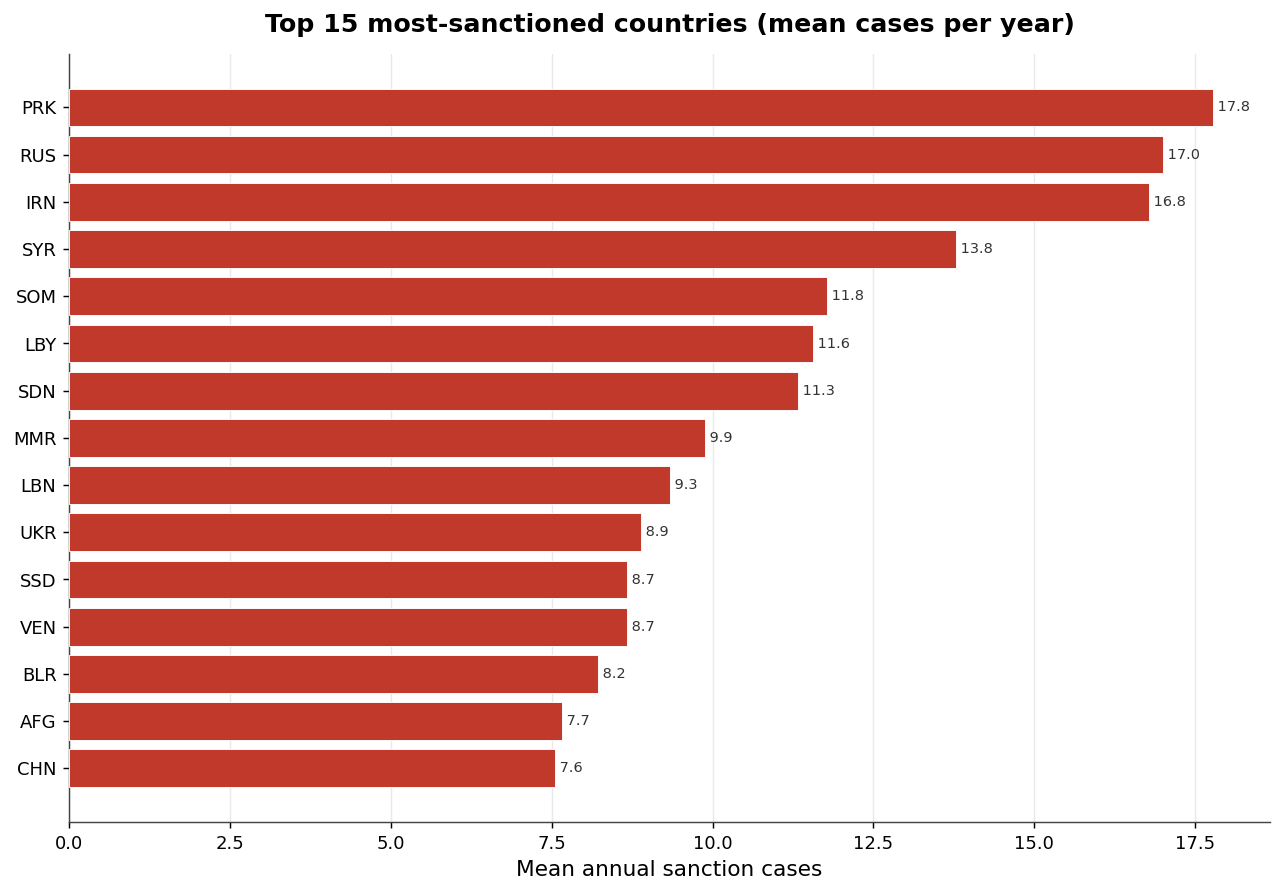

In [14]:
top = gsdb.groupby('iso3')['n_cases'].mean().nlargest(15)[::-1]
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top.index, top.values, color=RED, edgecolor='white', linewidth=0.5, zorder=3)
for i, v in enumerate(top.values):
    ax.text(v, i, f' {v:.1f}', va='center', fontsize=8, color='#333333')
ax.set_xlabel('Mean annual sanction cases'); ax.set_title('Top 15 most-sanctioned countries (mean cases per year)', pad=12)
ax.grid(axis='y', visible=False); fig.tight_layout(); plt.show()

The most-sanctioned countries are exactly the expected pariah and conflict states: North Korea (17.8 cases/yr), Russia (17.0), and Iran (16.8) lead, followed by Syria, Somalia, Libya, Sudan, Myanmar, Lebanon, Ukraine, South Sudan, Venezuela, Belarus, Afghanistan, and China.

Sanctions against Russia over time: number of cases and number of distinct senders.

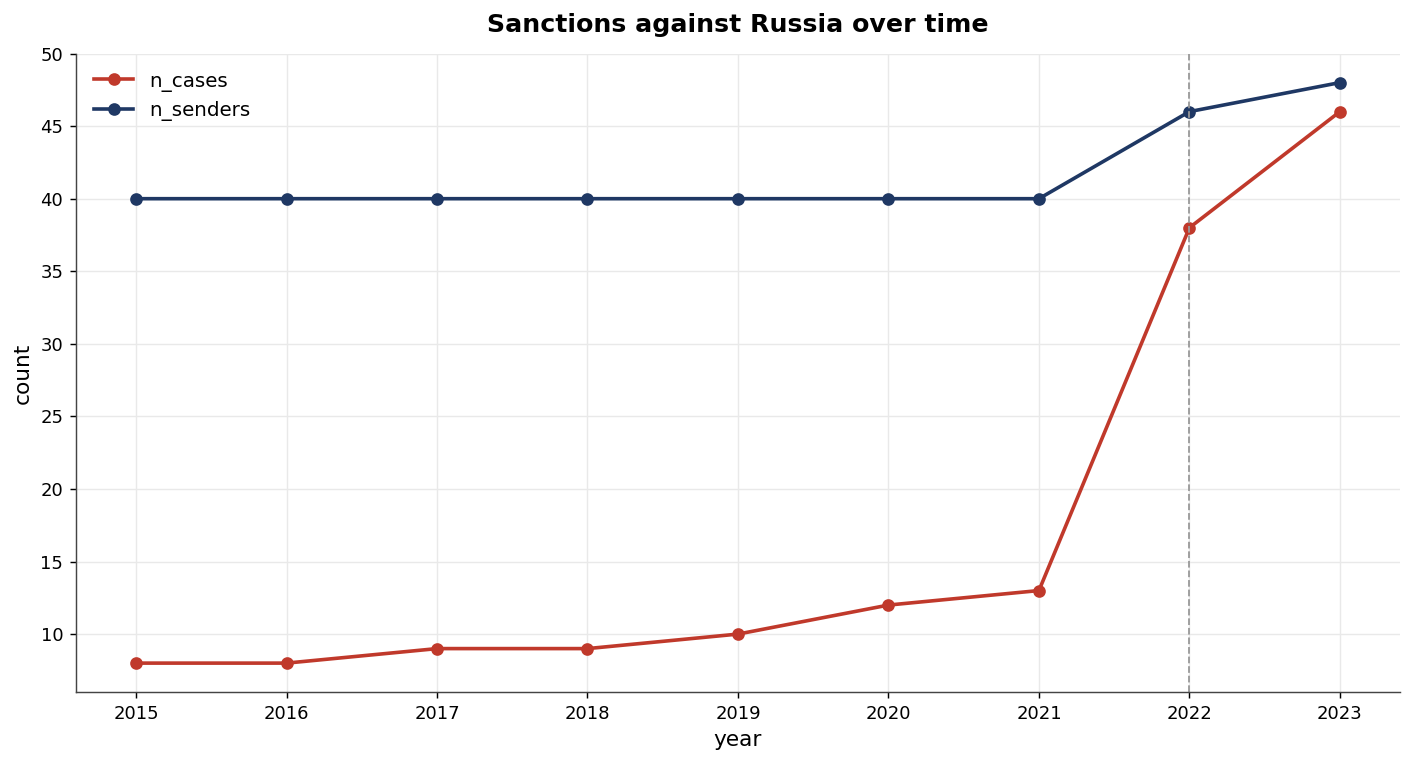

In [15]:
r = gsdb[gsdb.iso3 == 'RUS'].sort_values('year')
fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(r.year, r.n_cases, marker='o', color=RED, lw=2, label='n_cases')
ax.plot(r.year, r.n_senders, marker='o', color=NAVY, lw=2, label='n_senders')
ax.axvline(2022, color='#999999', ls='--', lw=1)
ax.set_xlabel('year'); ax.set_ylabel('count'); ax.set_title('Sanctions against Russia over time', pad=12)
ax.legend(); fig.tight_layout(); plt.show()

The clearest story in the data. Russia's case count slowly increases from 2015 to 2021, then jumps sharply in 2022 and 2023 after the invasion.

Global sanctions activity per year: how many distinct countries are sanctioned and the total number of sanction cases in force, to see the overall trend.

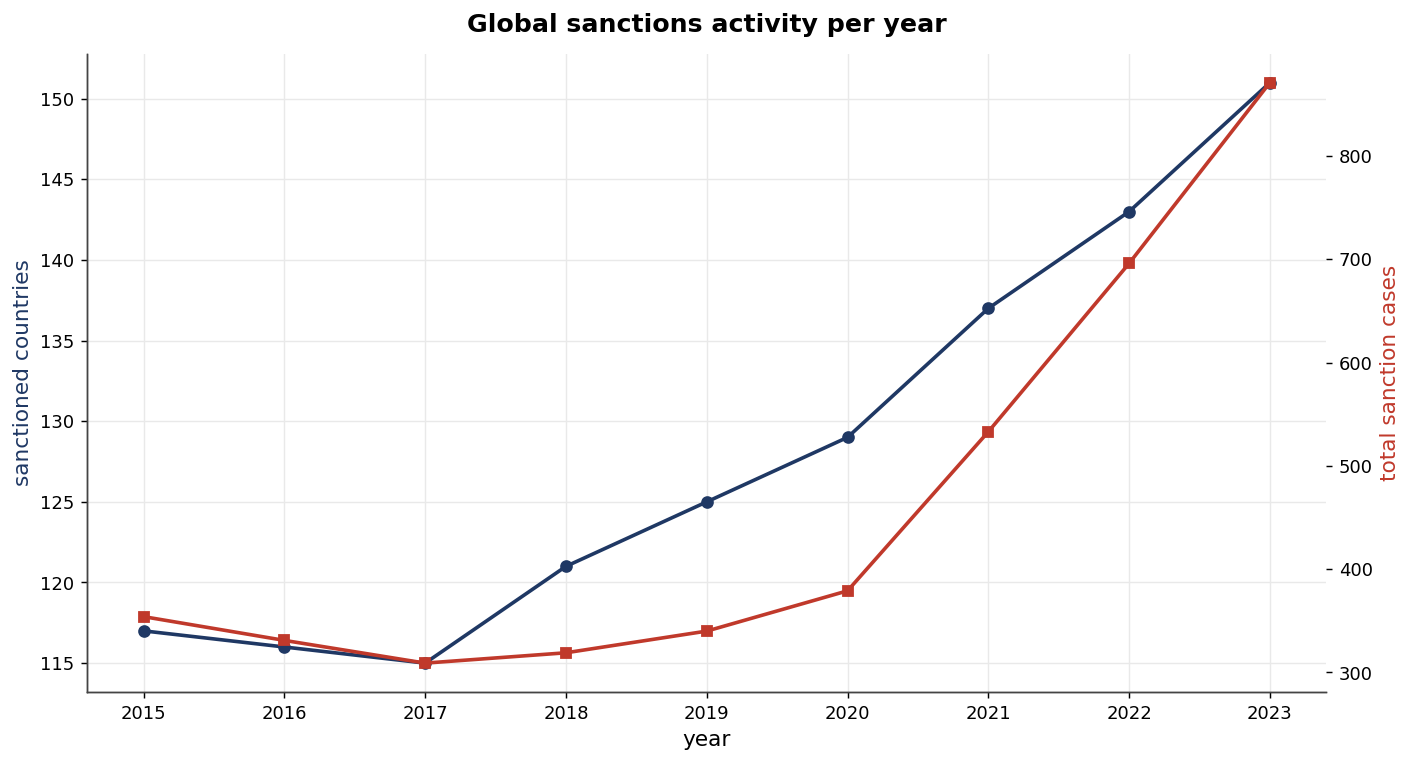

In [16]:
by = gsdb.groupby('year').agg(countries=('iso3', 'nunique'), total_cases=('n_cases', 'sum'))
fig, ax1 = plt.subplots(figsize=(11, 6))
ax1.plot(by.index, by.countries, marker='o', color=NAVY, lw=2, label='sanctioned countries')
ax1.set_xlabel('year'); ax1.set_ylabel('sanctioned countries', color=NAVY)
ax2 = ax1.twinx()
ax2.plot(by.index, by.total_cases, marker='s', color=RED, lw=2, label='total cases')
ax2.set_ylabel('total sanction cases', color=RED); ax2.grid(False)
ax1.set_title('Global sanctions activity per year', pad=12); fig.tight_layout(); plt.show()

Sanctions activity accelerates over the period. The number of distinct sanctioned countries rises steadily from 117 (2015) to 151 (2023).

I check redundancy among the nine features with a Spearman correlation heatmap, to see whether any pair is nearly the same signal (for example n_cases and n_senders).

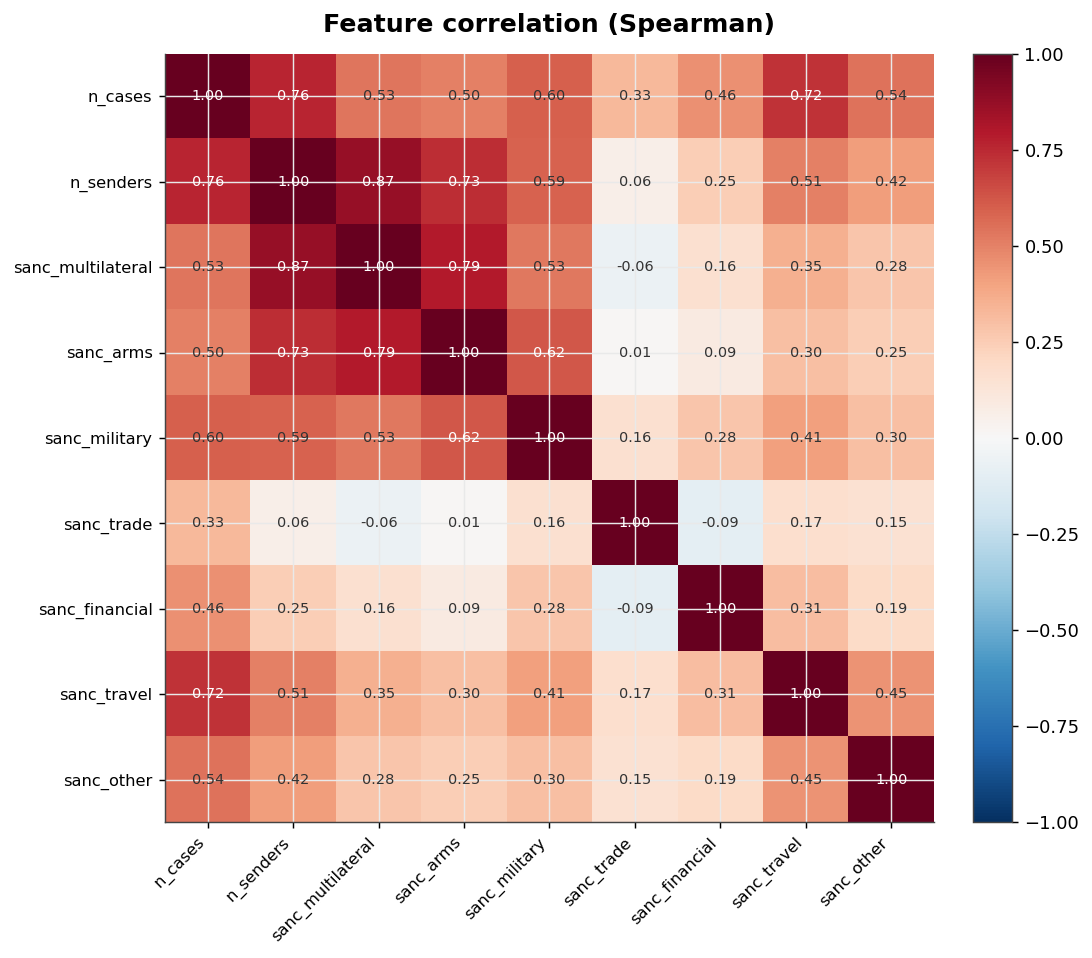

In [17]:
corr = gsdb[feats].corr(method='spearman')
fig, ax = plt.subplots(figsize=(9, 7.5))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(feats))); ax.set_xticklabels(feats, rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(len(feats))); ax.set_yticklabels(feats, fontsize=9)
for i in range(len(feats)):
    for j in range(len(feats)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center',
                color='white' if abs(corr.iloc[i, j]) > 0.6 else '#333333', fontsize=8)
fig.colorbar(im, fraction=0.046, pad=0.04); ax.set_title('Feature correlation (Spearman)', pad=12)
fig.tight_layout(); plt.show()

Most pairs are below the 0.90 bar. The strongest links are sanc_multilateral with n_senders (0.87), sanc_arms with sanc_multilateral (0.79), and n_senders with n_cases (0.76).Each of these captures a distinct facet (breadth vs count vs channel), so I keep all nine.

I made an interactive sanctions timeline to pick one or two countries and compare sanctions trajectories.

In [22]:
from ipywidgets import interact, Dropdown, Layout

countries = sorted(gsdb.iso3.unique())
opts = ['(none)'] + countries
WSTYLE = {'description_width': '110px'}
WIDE = Layout(width='430px')
CCOLORS = [RED, NAVY]

def sanctions_timeline(country_1='RUS', country_2='UKR', metric='n_cases'):
    sel = [c for c in [country_1, country_2] if c != '(none)']
    show = ['n_cases', 'n_senders'] if metric == 'both' else [metric]
    fig, ax = plt.subplots(figsize=(11, 6))
    for c, col in zip(sel, CCOLORS):
        s = gsdb[gsdb.iso3 == c].sort_values('year')
        for m in show:
            ls, mk = ('-', 'o') if m == 'n_cases' else ('--', 's')
            lbl = f'{c} {m}' if (len(sel) > 1 or len(show) > 1) else c
            ax.plot(s.year, s[m], ls=ls, marker=mk, color=col, lw=2, label=lbl)
    ax.axvline(2022, color='#999999', ls=':', lw=1)
    ax.set_xlabel('year'); ax.set_ylabel('count')
    title = 'Sanctions over time: ' + ' vs '.join(sel) if sel else 'Sanctions over time'
    ax.set_title(title, pad=12); ax.legend(); plt.show()

interact(sanctions_timeline,
  country_1=Dropdown(options=countries, value='RUS', description='Country 1', style=WSTYLE, layout=WIDE),
  country_2=Dropdown(options=opts, value='UKR', description='Country 2', style=WSTYLE, layout=WIDE),
  metric=Dropdown(options=['n_cases', 'n_senders', 'both'], value='n_cases', description='Metric', style=WSTYLE, layout=WIDE))

interactive(children=(Dropdown(description='Country 1', index=123, layout=Layout(width='430px'), options=('AFG…

<function __main__.sanctions_timeline(country_1='RUS', country_2='UKR', metric='n_cases')>

RUS and UKR sit at similar, low sanction counts through 2018. RUS climbs gradually from 2019, then jumps sharply at the 2022 invasion line to 38, reaching 46 by 2023. UKR rises too, but at a much lower rate.

## 5. Validate and Save

I check the final per-country-year table for duplicate iso3-year keys and any missing values before saving.

In [20]:
print('rows:', len(gsdb), '| countries:', gsdb.iso3.nunique(), '| years:', gsdb.year.min(), '-', gsdb.year.max())
print('duplicate iso3-year keys:', int(gsdb.duplicated(['iso3', 'year']).sum()))
gsdb.isna().sum().to_frame('n_missing')

rows: 1154 | countries: 156 | years: 2015 - 2023
duplicate iso3-year keys: 0


,n_missing
iso3,0
year,0
n_cases,0
n_senders,0
sanc_multilateral,0
sanc_arms,0
sanc_military,0
sanc_trade,0
sanc_financial,0
sanc_travel,0


The table is clean: 1,154 country-years across 156 countries, 2015 to 2023, with no duplicate iso3-year keys and zero missing values in any column.

I order the columns, sort by country and year, confirm the keys are unique, and save the clean per-country-year table (2015 to 2023).

In [23]:
cols = ['iso3', 'year', 'n_cases', 'n_senders', 'sanc_multilateral'] + [f'sanc_{t}' for t in TYPES]
out = gsdb[cols].sort_values(['iso3', 'year']).reset_index(drop=True)
assert out.duplicated(['iso3', 'year']).sum() == 0, 'duplicate iso3-year keys!'
os.makedirs(OUT_DIR, exist_ok=True)
path = f'{OUT_DIR}/gsdb_clean.csv'
out.to_csv(path, index=False)
print('saved:', path, '|', out.shape, '| countries:', out.iso3.nunique())
out.head()

saved: /Users/oussamaennaciri/Documents/Education/Academique/Regis/MSDS692 S40 Data Science Practicum/data/interim/gsdb/gsdb_clean.csv | (1154, 11) | countries: 156


,iso3,year,n_cases,n_senders,sanc_multilateral,sanc_arms,sanc_military,sanc_trade,sanc_financial,sanc_travel,sanc_other
0,AFG,2015,6,192,1,1,1,0,1,1,1
1,AFG,2016,6,192,1,1,1,0,1,1,1
2,AFG,2017,6,192,1,1,1,0,1,1,1
3,AFG,2018,5,192,1,1,1,0,1,1,1
4,AFG,2019,5,192,1,1,1,0,1,1,1


Claude (Anthropic) was used only as a collaborator for writing code and polishing the notebooks. All analytical decisions, interpretations, and research were conducted independently by me.